In [3]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import os
import sys
from IPython.display import display

import keras
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Primeira família de DeepLearning testada será o CNN

In [4]:
#Carregando os Dados, testando primeiro para o FD001

motor = 'FD001'
X_train = np.load(f"../data/processed_data/X_train_{motor}.npz")['dados']
y_train = np.load(f"../data/processed_data/y_train_{motor}.npz")['dados']
X_test = np.load(f"../data/processed_data/X_test_{motor}.npz")['dados']
y_test = np.load(f"../data/processed_data/y_test_{motor}.npz")['dados']

print(f"Data Shape da CNN: {X_train.shape[1:]} (Ciclos, Sensores)")

Data Shape da CNN: (30, 19) (Ciclos, Sensores)


In [ ]:
#Construindo a Arquitetura da CNN 1D (Primeiro será feito um modelo simples)
#Posteriormente serão testados diversos hiperparâmetros 
model_cnn = Sequential([
    
    #Camada de Convolução: desliza um filtro de tamanho 3 pelos 30 ciclos temporais
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    #A cada 2 ciclos, reduz a dimensionalidade pela metade, guardando apenas os padrões mais importantes
    MaxPooling1D(pool_size=2),
    
    #Camada de Convolução mais profunda para padrões complexos, aplicado sobre os padrões extraídos da primeira camada
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    
    #Achatamento interno da rede para preparar os padrões extraídos para a decisão final, transformando em 1D
    Flatten(),
    
    #Camadas Densas de Decisão (cérebro da rede), com 64 neurônios
    Dense(64, activation='relu'),
    #Desliga 20% dos neurônios aleatoriamente para evitar Overfitting
    Dropout(0.2), 
    
    #Saída Linear (Previsão do RUL)
    Dense(1)
])

#Compilando o Modelo
model_cnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_cnn.summary()

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,697 (303.50 KB)

 Trainable params: 77,697 (303.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Treinamento da rede

#Early Stopping: para o treino se o erro na validação não cair por 5 épocas seguidas
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#Treinamento da rede
history = model_cnn.fit(
    X_train, y_train,
    epochs=50, 
    batch_size=64, 
    validation_split=0.2, 
    callbacks=[early_stop],
    verbose=1
)

#Avaliando no Teste
print("\nAvaliando o modelo nos dados de teste...")
y_pred = model_cnn.predict(X_test)

#Calculando as métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\nTreinamento Concluído!")
print(f"RMSE da CNN 1D no FD001: {rmse:.2f} ciclos")
print(f"MAE da CNN 1D no FD001: {mae:.2f} ciclos")

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 240.7210 - mae: 11.6842 - val_loss: 227.1188 - val_mae: 11.2288
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 242.6896 - mae: 11.7451 - val_loss: 220.2288 - val_mae: 11.2934
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 241.1011 - mae: 11.7340 - val_loss: 293.7599 - val_mae: 13.3736
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 236.6317 - mae: 11.5968 - val_loss: 230.0725 - val_mae: 11.6190
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 233.6112 - mae: 11.5795 - val_loss: 232.3125 - val_mae: 11.5838
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 228.0314 - mae: 11.3841 - val_loss: 260.4317 - val_mae: 12.5540
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 221.9223 - mae: 11.2615 - val_loss: 249.8772 - val_mae: 12.1583

valiando o modelo nos dados de teste...
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step

Treinamento Concluído!
RMSE da CNN 1D no FD001:

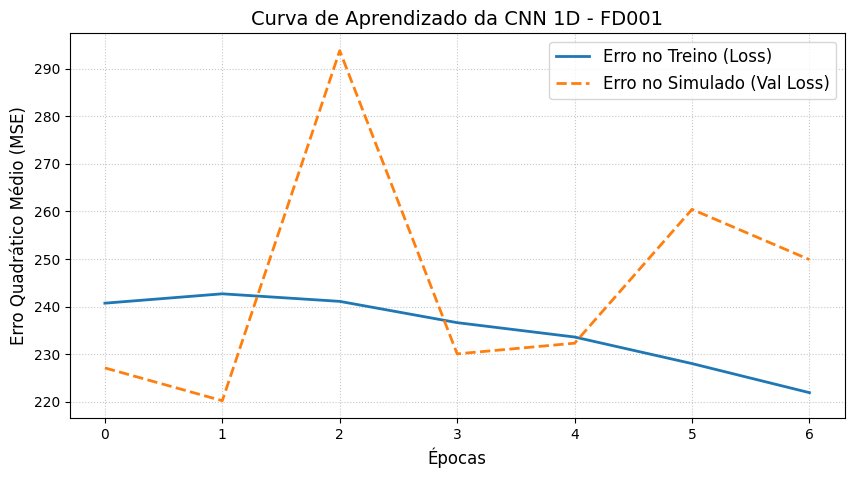

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Erro no Treino (Loss)', linewidth=2)
plt.plot(history.history['val_loss'], label='Erro no Simulado (Val Loss)', linewidth=2, linestyle='--')
plt.title('Curva de Aprendizado da CNN 1D - FD001', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Erro Quadrático Médio (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()